<a href="https://colab.research.google.com/github/AndresMontesDeOca/Analisis-de-Datos/blob/main/TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
data = pd.read_csv('smn_historico.csv', na_values=['S/D'])

In [10]:
print(data.info())
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   estacion      1176 non-null   object 
 1   provincia     1152 non-null   object 
 2   altura        1152 non-null   float64
 3   numero        1152 non-null   float64
 4   NroOACI       1140 non-null   object 
 5   LAT_decimal   1152 non-null   float64
 6   LON_decimal   1152 non-null   float64
 7   mes_txt       1176 non-null   object 
 8   prec_sup_1mm  1061 non-null   float64
 9   humedad       1110 non-null   float64
 10  nubosidad     1166 non-null   float64
 11  prec_mm       1061 non-null   float64
 12  temp          1167 non-null   float64
 13  temp_max      1158 non-null   float64
 14  temp_min      1124 non-null   float64
 15  viento        708 non-null    float64
dtypes: float64(12), object(4)
memory usage: 147.1+ KB
None


,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


In [11]:
data['provincia'].value_counts(dropna=False)

,count
provincia,
BUENOS AIRES,240
CORDOBA,96
SANTA CRUZ,72
ANTARTIDA,72
SANTA FE,60
RIO NEGRO,60
MENDOZA,60
MISIONES,48
ENTRE RIOS,36


In [22]:
NEA = ['MISIONES', 'CORRIENTES', 'FORMOSA', 'CHACO']
data= data[data['provincia'].isin(NEA)]

data['provincia'].value_counts()

,count
provincia,
MISIONES,48
CORRIENTES,36
FORMOSA,24
CHACO,24


In [28]:
len(data['estacion'].str.strip().unique())

11

In [32]:
data.describe()

,altura,numero,LAT_decimal,LON_decimal,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
count,132.000000,132.000000,132.000000,132.000000,125.000000,128.000000,128.000000,125.000000,128.000000,128.000000,116.000000,84.000000
mean,184.909091,87183.272727,-27.207576,-57.368182,6.850400,74.543750,3.787500,129.837600,21.136719,27.343750,16.106897,11.196429
std,216.558842,83.949921,1.550102,2.238916,2.054563,5.565979,0.451245,56.956018,4.061396,4.247737,3.748709,3.387342
min,52.000000,87078.000000,-30.250000,-60.583333,1.400000,59.200000,2.800000,11.900000,13.100000,18.900000,8.800000,4.500000
25%,60.000000,87148.000000,-27.483333,-59.033333,5.900000,70.650000,3.500000,87.800000,17.200000,23.775000,12.775000,9.650000
50%,93.000000,87163.000000,-27.383333,-57.633333,7.100000,74.450000,3.700000,140.600000,21.600000,27.650000,16.500000,11.200000
75%,270.000000,87187.000000,-26.200000,-55.116667,8.000000,78.800000,4.000000,170.800000,24.825000,31.100000,19.325000,13.625000
max,815.000000,87393.000000,-24.700000,-53.666667,12.000000,88.600000,5.300000,277.900000,28.300000,35.500000,22.500000,19.700000


In [35]:
data.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
120,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,Ene,11.9,77.6,5.3,207.1,22.9,28.1,19.0,NaN
121,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,Feb,11.0,78.6,5.2,189.1,22.6,27.6,18.8,NaN
122,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,Mar,10.1,77.9,4.8,181.0,21.7,26.9,17.9,NaN
123,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,Abr,7.7,77.7,4.5,173.9,19.6,24.4,15.9,NaN
124,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,May,8.6,79.0,4.7,196.1,16.2,20.6,12.9,NaN


<Axes: >

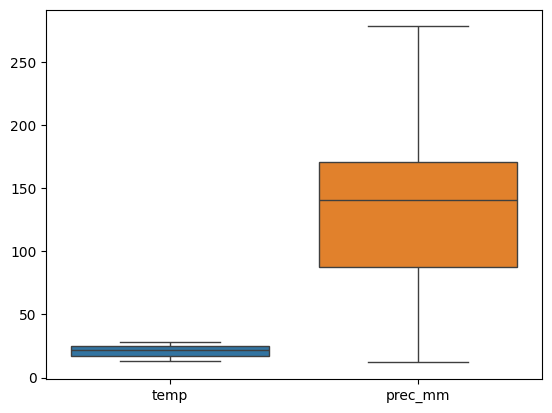

In [50]:
sns.boxplot(data=data[['temp', 'prec_mm']], showfliers=True)

In [65]:
formosa = data.query("provincia == 'FORMOSA'")
formosa

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
372,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.2,-58.216667,Ene,7.6,71.5,4.0,163.5,27.7,34.1,22.5,12.4
373,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.2,-58.216667,Feb,7.4,74.2,4.0,135.6,26.9,33.0,22.0,11.5
374,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.2,-58.216667,Mar,6.8,76.4,3.7,138.2,25.6,31.7,20.6,10.8
375,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.2,-58.216667,Abr,6.9,78.9,3.8,159.6,22.7,28.6,18.0,10.5
376,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.2,-58.216667,May,6.0,81.2,4.1,110.1,19.0,24.5,14.6,11.2
377,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.2,-58.216667,Jun,4.7,81.0,4.5,60.3,17.3,22.8,13.1,12.2
378,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.2,-58.216667,Jul,3.4,76.4,4.0,41.0,16.4,22.7,11.5,12.1
379,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.2,-58.216667,Ago,3.6,70.3,3.5,34.8,18.3,25.4,12.7,14.8
380,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.2,-58.216667,Sep,5.7,69.3,3.8,74.8,20.4,27.2,14.7,14.3
381,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.2,-58.216667,Oct,8.3,72.4,4.2,150.3,23.4,29.5,18.2,15.4


In [66]:
meses_dict = {
    'Ene': '01 - Ene',
    'Feb': '02 - Feb',
    'Mar': '03 - Mar',
    'Abr': '04 - Abr',
    'May': '05 - May',
    'Jun': '06 - Jun',
    'Jul': '07 - Jul',
    'Ago': '08 - Ago',
    'Sep': '09 - Sep',
    'Oct': '10 - Oct',
    'Nov': '11 - Nov',
    'Dic': '12 - Dic'
}

formosa['mes_txt'] = formosa['mes_txt'].map(meses_dict)



/tmp/ipykernel_267/3127854407.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  formosa['mes_txt'] = formosa['mes_txt'].map(meses_dict)


<Axes: xlabel='mes_txt'>

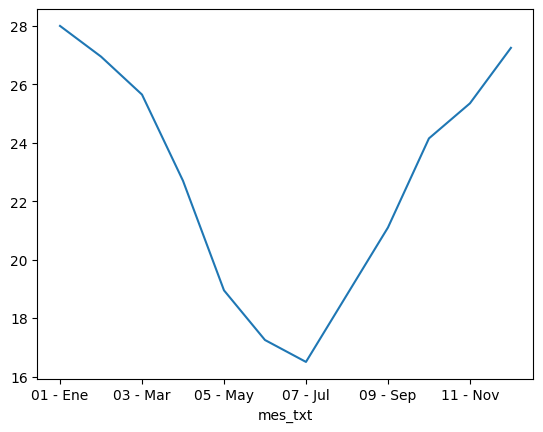

In [69]:
formosa.groupby(['mes_txt'])['temp'].mean().plot(kind='line')

<Axes: xlabel='mes_txt'>

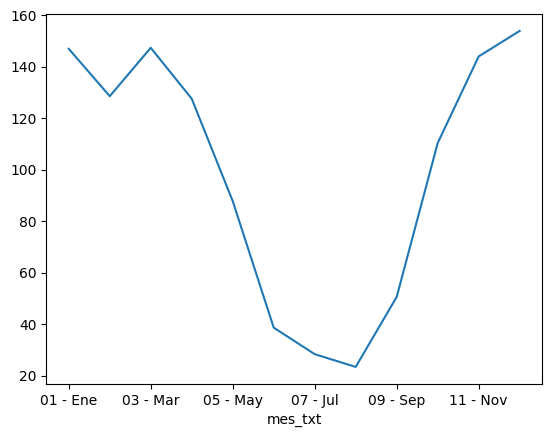

In [70]:
formosa.groupby(['mes_txt'])['prec_mm'].mean().plot(kind='line')

<Axes: xlabel='mes_txt'>

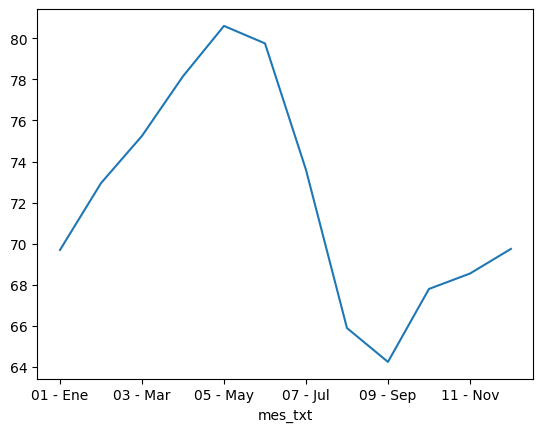

In [73]:
formosa.groupby(['mes_txt'])['humedad'].mean().plot(kind='line')